In [2]:
#Analise dos Microdados do ENEM

In [3]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

In [5]:
microdadosEnem = pd.read_csv("../../microdados_enem_2023/DADOS/MICRODADOS_ENEM_2023.csv", sep=";", encoding='ISO-8859-1')

In [6]:
microdadosEnem.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210059085136,2023,14,M,2,1,1,1,17,1,...,C,C,B,B,A,B,B,A,A,B
1,210059527735,2023,12,M,2,1,0,1,16,1,...,B,A,B,B,A,A,C,A,D,B
2,210061103945,2023,6,F,1,1,1,1,0,1,...,B,A,A,B,A,A,A,A,A,B
3,210060214087,2023,2,F,1,3,1,2,0,2,...,A,A,A,B,A,A,D,A,A,B
4,210059980948,2023,3,F,1,3,1,2,0,2,...,A,A,A,B,A,A,B,A,A,A


In [7]:
microdadosEnem.columns.values

array(['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO',
       'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE',
       'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO',
       'IN_TREINEIRO', 'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC',
       'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC',
       'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA',
       'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA',
       'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC',
       'TP_PRESENCA_MT', 'CO_PROVA_CN', 'CO_PROVA_CH', 'CO_PROVA_LC',
       'CO_PROVA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC',
       'NU_NOTA_MT', 'TX_RESPOSTAS_CN', 'TX_RESPOSTAS_CH',
       'TX_RESPOSTAS_LC', 'TX_RESPOSTAS_MT', 'TP_LINGUA',
       'TX_GABARITO_CN', 'TX_GABARITO_CH', 'TX_GABARITO_LC',
       'TX_GABARITO_MT', 'TP_STATUS_REDACAO', 'NU_NOTA_COMP1',
       'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5',
       'NU_NOTA_REDACAO', 'Q001', 'Q002', '

In [8]:
colunasSelecionadas = ['NU_INSCRICAO','NU_NOTA_MT','NU_NOTA_REDACAO','Q001','Q002']

In [9]:
microdadosSelecionados = microdadosEnem.filter(items = colunasSelecionadas)

In [10]:
microdadosSelecionados = microdadosSelecionados.dropna()

In [11]:
microdadosSelecionados.head()

,NU_INSCRICAO,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002
2,210061103945,363.2,700.0,H,E
3,210060214087,466.7,880.0,D,D
4,210059980948,338.3,560.0,B,B
9,210060801601,680.2,600.0,H,E
10,210059085130,736.3,860.0,F,C


In [12]:
Q1_Q2_dicionario = {
    'A' : 'Nunca estudou',
    'B' : 'Não completou a 4ª série/5º ano do Ensino Fundamental.',
    'C' : 'Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.',
    'D' : 'Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.',
    'E' : 'Completou o Ensino Médio, mas não completou a Faculdade.',
    'F' : 'Completou a Faculdade, mas não completou a Pós-graduação.',
    'G' : 'Completou a Pós-graduação.',
    'H' : 'Não sei.'}

In [13]:
microdadosSelecionados.filter(items = ['Q001', 'NU_INSCRICAO']).groupby('Q001').count()

,NU_INSCRICAO
Q001,
A,96339
B,410065
C,331431
D,297233
E,809174
F,269803
G,214608
H,249611


In [15]:
microdadosSelecionados.filter(items = ['Q002', 'NU_INSCRICAO']).groupby('Q002').count()

,NU_INSCRICAO
Q002,
A,57771
B,280378
C,265666
D,303957
E,970947
F,359218
G,362886
H,77441


In [17]:
orfaos = microdadosSelecionados[(microdadosSelecionados['Q001'] == 'H') & 
                                (microdadosSelecionados['Q002'] == 'H')]
orfaos[['Q001', 'Q002']].groupby(['Q001', 'Q002']).size()

Q001  Q002
H     H       53602
dtype: int64

In [19]:
microdadosSelecionados['NO_Q001'] = [Q1_Q2_dicionario[resp] for resp in microdadosSelecionados.Q001]

In [20]:
microdadosSelecionados['NO_Q002'] = [Q1_Q2_dicionario[resp] for resp in microdadosSelecionados.Q002]

In [15]:
microdadosSelecionados.head()

,NU_INSCRICAO,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,NO_Q001,NO_Q002
2,210061103945,363.2,700.0,H,E,Não sei.,"Completou o Ensino Médio, mas não completou a ..."
3,210060214087,466.7,880.0,D,D,Completou a 8ª série/9º ano do Ensino Fundamen...,Completou a 8ª série/9º ano do Ensino Fundamen...
4,210059980948,338.3,560.0,B,B,Não completou a 4ª série/5º ano do Ensino Fund...,Não completou a 4ª série/5º ano do Ensino Fund...
9,210060801601,680.2,600.0,H,E,Não sei.,"Completou o Ensino Médio, mas não completou a ..."
10,210059085130,736.3,860.0,F,C,"Completou a Faculdade, mas não completou a Pós...","Completou a 4ª série/5º ano, mas não completou..."


In [16]:
microdadosSelecionados.filter(items = ['NO_Q001', 'NU_INSCRICAO']).groupby('NO_Q001').count().sort_values(by = 'NU_INSCRICAO', ascending = False)

,NU_INSCRICAO
NO_Q001,
"Completou o Ensino Médio, mas não completou a Faculdade.",809174
Não completou a 4ª série/5º ano do Ensino Fundamental.,410065
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",331431
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",297233
"Completou a Faculdade, mas não completou a Pós-graduação.",269803
Não sei.,249611
Completou a Pós-graduação.,214608
Nunca estudou,96339


In [17]:
microdadosSelecionados.filter(items = ['NO_Q002', 'NU_INSCRICAO']).groupby('NO_Q002').count().sort_values(by = 'NU_INSCRICAO', ascending = False)

,NU_INSCRICAO
NO_Q002,
"Completou o Ensino Médio, mas não completou a Faculdade.",970947
Completou a Pós-graduação.,362886
"Completou a Faculdade, mas não completou a Pós-graduação.",359218
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",303957
Não completou a 4ª série/5º ano do Ensino Fundamental.,280378
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",265666
Não sei.,77441
Nunca estudou,57771


In [18]:
microdadosSelecionados.filter(items = ['NO_Q001', 'NU_NOTA_MT']).groupby('NO_Q001').mean().sort_values(by = 'NU_NOTA_MT', ascending = False)

,NU_NOTA_MT
NO_Q001,
Completou a Pós-graduação.,632.876209
"Completou a Faculdade, mas não completou a Pós-graduação.",613.289055
"Completou o Ensino Médio, mas não completou a Faculdade.",545.235226
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",517.941732
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",506.253618
Não sei.,496.942199
Não completou a 4ª série/5º ano do Ensino Fundamental.,483.230915
Nunca estudou,455.176781


In [19]:
microdadosSelecionados.filter(items = ['NO_Q002', 'NU_NOTA_MT']).groupby('NO_Q002').mean().sort_values(by = 'NU_NOTA_MT', ascending = False)

,NU_NOTA_MT
NO_Q002,
Completou a Pós-graduação.,609.014058
"Completou a Faculdade, mas não completou a Pós-graduação.",594.036821
"Completou o Ensino Médio, mas não completou a Faculdade.",532.340048
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",502.608107
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",491.493473
Não sei.,483.408041
Não completou a 4ª série/5º ano do Ensino Fundamental.,472.674070
Nunca estudou,444.722695


In [20]:
microdadosSelecionados.filter(items = ['NO_Q001', 'NU_NOTA_REDACAO']).groupby('NO_Q001').mean().sort_values(by = 'NU_NOTA_REDACAO', ascending = False)

,NU_NOTA_REDACAO
NO_Q001,
Completou a Pós-graduação.,737.590211
"Completou a Faculdade, mas não completou a Pós-graduação.",715.444232
"Completou o Ensino Médio, mas não completou a Faculdade.",644.933105
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",612.257185
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",597.575906
Não sei.,570.066223
Não completou a 4ª série/5º ano do Ensino Fundamental.,566.798922
Nunca estudou,521.734085


In [21]:
microdadosSelecionados.filter(items = ['NO_Q002', 'NU_NOTA_REDACAO']).groupby('NO_Q002').mean().sort_values(by = 'NU_NOTA_REDACAO', ascending = False)

,NU_NOTA_REDACAO
NO_Q002,
Completou a Pós-graduação.,716.739196
"Completou a Faculdade, mas não completou a Pós-graduação.",697.339276
"Completou o Ensino Médio, mas não completou a Faculdade.",629.480765
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",591.582362
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",575.631507
Não completou a 4ª série/5º ano do Ensino Fundamental.,548.656171
Não sei.,531.189938
Nunca estudou,497.020997


In [26]:
colunasSelecionadas = ['NU_INSCRICAO','SG_UF_PROVA','NU_NOTA_MT','NU_NOTA_REDACAO','Q001','Q002']

In [31]:
microdadosSelecionados['SG_UF_PROVA'] = microdadosEnem.SG_UF_PROVA

In [32]:
microdadosSelecionados.head()

,NU_INSCRICAO,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,NO_Q001,NO_Q002,SG_UF_PROVA
2,210061103945,363.2,700.0,H,E,Não sei.,"Completou o Ensino Médio, mas não completou a ...",RS
3,210060214087,466.7,880.0,D,D,Completou a 8ª série/9º ano do Ensino Fundamen...,Completou a 8ª série/9º ano do Ensino Fundamen...,CE
4,210059980948,338.3,560.0,B,B,Não completou a 4ª série/5º ano do Ensino Fund...,Não completou a 4ª série/5º ano do Ensino Fund...,CE
9,210060801601,680.2,600.0,H,E,Não sei.,"Completou o Ensino Médio, mas não completou a ...",SP
10,210059085130,736.3,860.0,F,C,"Completou a Faculdade, mas não completou a Pós...","Completou a 4ª série/5º ano, mas não completou...",RN


In [34]:
microdadosSelecionados.filter(items=['NU_NOTA_REDACAO', 'NO_Q002'])\
                    .where(microdadosSelecionados.SG_UF_PROVA == 'RJ')\
                    .groupby('NO_Q002')\
                    .mean().sort_values(by='NU_NOTA_REDACAO', ascending = False)

,NU_NOTA_REDACAO
NO_Q002,
Completou a Pós-graduação.,744.440490
"Completou a Faculdade, mas não completou a Pós-graduação.",716.394352
"Completou o Ensino Médio, mas não completou a Faculdade.",638.958282
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",602.751484
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",585.740260
Não completou a 4ª série/5º ano do Ensino Fundamental.,548.735616
Não sei.,543.163287
Nunca estudou,478.564555


In [42]:
microdadosSelecionados.filter(items=['SG_UF_PROVA','NU_NOTA_REDACAO', 'NO_Q002'])\
                    .groupby(['SG_UF_PROVA','NO_Q002'])\
                    .mean().sort_values(by='NU_NOTA_REDACAO', ascending = False)

,,NU_NOTA_REDACAO
SG_UF_PROVA,NO_Q002,
CE,Completou a Pós-graduação.,751.118542
SE,Completou a Pós-graduação.,747.351351
PB,Completou a Pós-graduação.,745.908818
RJ,Completou a Pós-graduação.,744.440490
MG,Completou a Pós-graduação.,743.290473
...,...,...
RO,Nunca estudou,471.266541
TO,Nunca estudou,467.058824
DF,Nunca estudou,464.085561


Text(0.03, 0.69, 'A : Nunca estudou\nB : Não completou a 4ª série/5º ano do Ensino Fundamental.\nC : Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.\nD : Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.\nE : Completou o Ensino Médio, mas não completou a Faculdade.\nF : Completou a Faculdade, mas não completou a Pós-graduação.\nG : Completou a Pós-graduação.\nH : Não sei.\n')

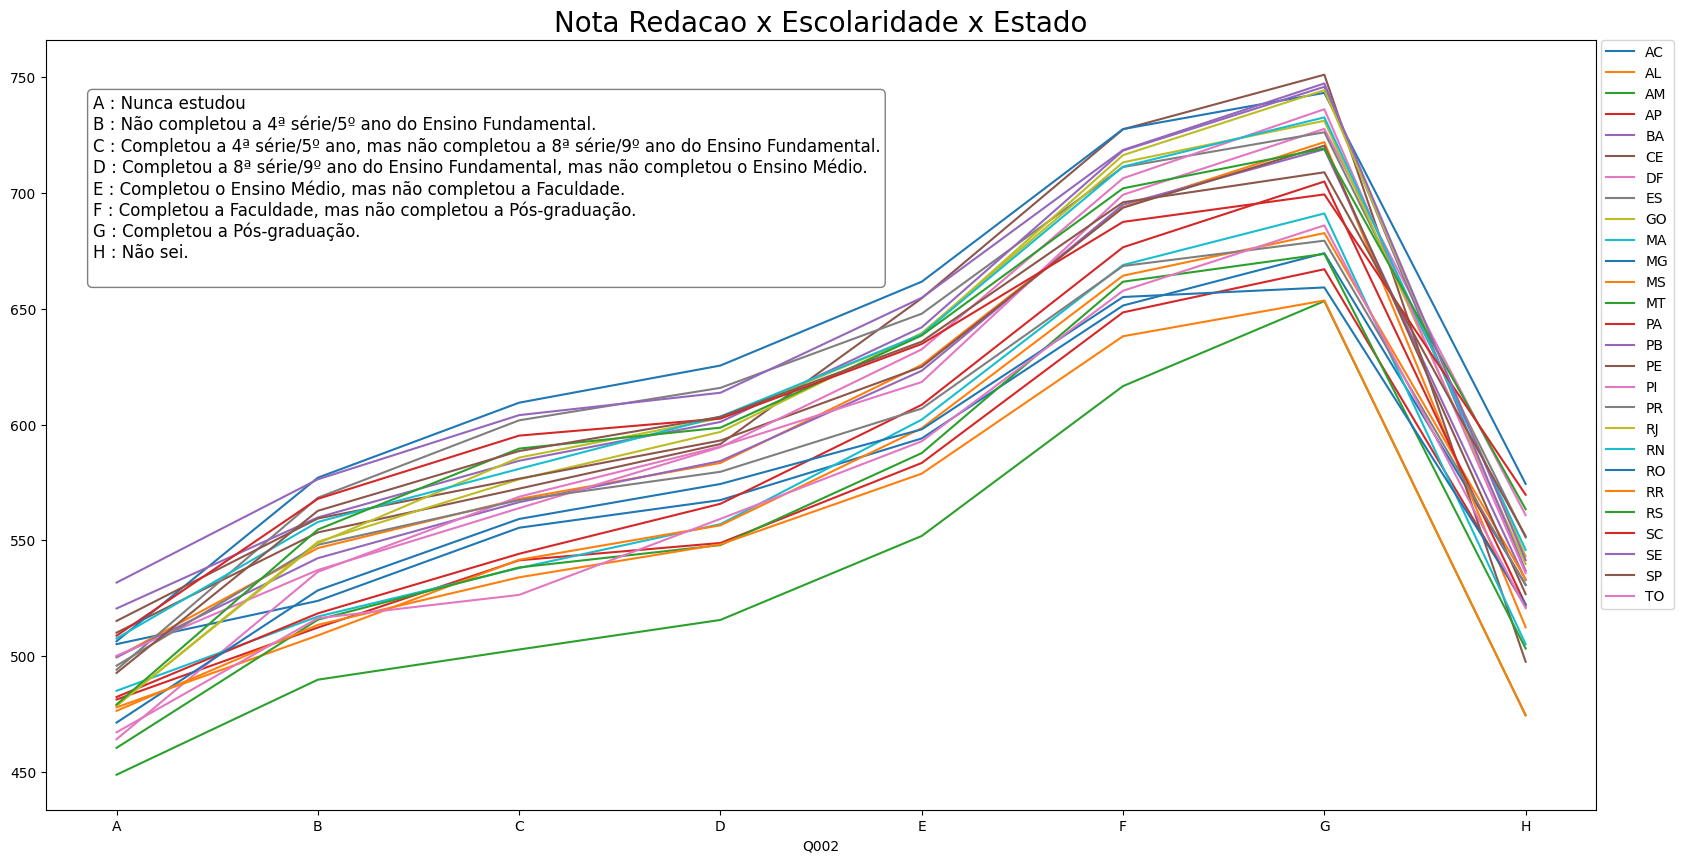

In [90]:
#fig, ax = plt.subplots(figsize=(20, 10))
#plt.suptitle('Nota Redacao x Escolaridade x Estado')

ax = microdadosSelecionados.filter(items=['SG_UF_PROVA','Q002','NU_NOTA_REDACAO'])\
                    .groupby(['Q002','SG_UF_PROVA'])\
                    .mean().sort_values(by='NU_NOTA_REDACAO', ascending = False)\
                    .unstack().plot(figsize=(20,10))

ax.set_title('Nota Redacao x Escolaridade x Estado', fontsize=20)
#ax.legend(bbox_to_anchor=(1.05,1), loc=0, borderaxespad=0.)

handles, labels = ax.get_legend_handles_labels()

import re
edited_labels = [re.search(',\s(.+?)\)', label).group(1) for label in labels]
ax.legend(edited_labels, bbox_to_anchor=(1.05,1), loc=0, borderaxespad=0.)

textdictQ002 = ""
for key, value in Q1_Q2_dicionario.items():
    textdictQ002 = textdictQ002 + "{k} : {v}\n".format(k=key, v=value)

ax.text(0.03, 0.69, textdictQ002, transform = ax.transAxes, fontsize = 12, 
        bbox={'boxstyle' : 'round', 'facecolor' : 'white', 'alpha' : 0.5})

In [21]:
microdadosSelecionados.filter(items = ['NO_Q001', 'NU_INSCRICAO', 'TP_SEXO']).groupby('NO_Q001').count().sort_values(by = 'NU_INSCRICAO', ascending = False)

,NU_INSCRICAO
NO_Q001,
"Completou o Ensino Médio, mas não completou a Faculdade.",809174
Não completou a 4ª série/5º ano do Ensino Fundamental.,410065
"Completou a 4ª série/5º ano, mas não completou a 8ª série/9º ano do Ensino Fundamental.",331431
"Completou a 8ª série/9º ano do Ensino Fundamental, mas não completou o Ensino Médio.",297233
"Completou a Faculdade, mas não completou a Pós-graduação.",269803
Não sei.,249611
Completou a Pós-graduação.,214608
Nunca estudou,96339
